# Deep Learning Exam

This notebook is the project for the Deep Learning exam taken on July 16th 2024.

## Data Loading

**Note**: the original dataset is no longer available. You need to provide your own satellite imagery data with the following format:
- images: shape (N, 256, 256, 3)
- masks: shape (N, 256, 256, 1) with 6 classes

In [ ]:
# original data loading code (dataset no longer available)
"""
import urllib.request
import zipfile
zip_url = "https://github.com/SebastianoPietra/DL_exam/raw/main/input_data.zip"
zip_path, _ = urllib.request.urlretrieve(zip_url)
target_folder = "temp"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(target_folder)
data_path = f"{target_folder}/input_data.pkl"
import pickle as pk
with open(data_path, 'rb') as f:
    dd = pk.load(f)
imgs = dd['imgs']
masks = dd['masks']
"""

# load your own data here
# expected: imgs (N, 256, 256, 3) and masks (N, 256, 256, 1) with 6 classes
# imgs = np.load('your_images.npy')
# masks = np.load('your_masks.npy')

## Install and import necessary libraries

All the libraries are grouped here to find them more easily when in need.

In [ ]:
! pip install imgaug keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 9.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Conv2DTranspose, concatenate, Lambda
from keras.models import Model, load_model
from keras import activations
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import backend as K
import keras_tuner as kt
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

import imgaug.augmenters as iaa
import shutil
import os
from ipywidgets import interact, IntSlider, Dropdown, VBox, interactive

## Data Preprocessing

### Data reduction
This step proved necessary during the various runs, for computational efficiency purposes. A subset of data is taken from the original datasets based on a given percentage that we can decide when calling the function. The indeces are randomly preselected so they can directly be used for both "imgs" and "masks" sets, and there will be no problem of non matching indices.

In [ ]:
def select_data_subset(imgs, masks, percentage):

    # percentage must be between 0 and 1
    if not (0 <= percentage <= 1):
        raise ValueError("Percentage must be between 0 and 1.")

    num_samples = int(len(imgs) * percentage)

    # we then generate the list of all indices and shuffle, then we proceed to the selection
    indices = np.arange(len(imgs))
    np.random.shuffle(indices)
    selected_indices = indices[:num_samples]

    # finally we can use the selected indices to get the subsets of images and masks
    imgs_subset = imgs[selected_indices]
    masks_subset = masks[selected_indices]

    return imgs_subset, masks_subset

In [ ]:
selection_percentage = 0.3
imgs_subset, masks_subset = select_data_subset(imgs, masks, selection_percentage)

print(f"Selected {len(imgs_subset)} images and masks out of {len(imgs)} total.")

Selected 391 images and masks out of 1305 total.


### Checking images and masks
We print the new subsets' shapes and their first instances to check everything went fine.

In [ ]:
print(imgs_subset.shape)
print(masks_subset.shape)

(391, 256, 256, 3)
(391, 256, 256, 1)


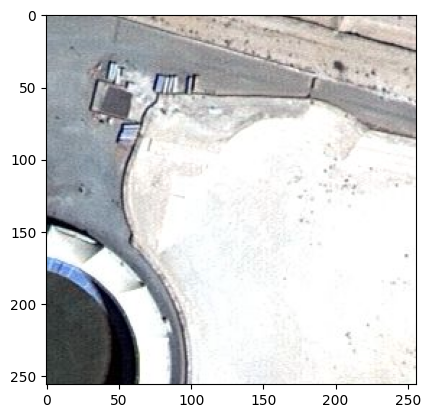

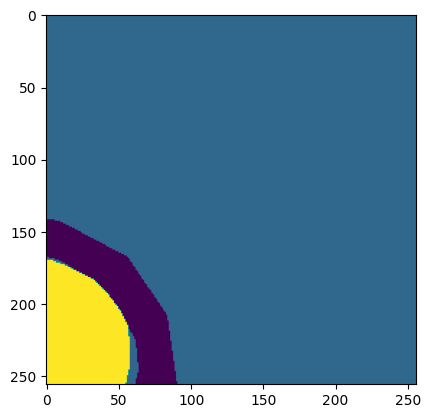

In [ ]:
plt.imshow(imgs_subset[0])
plt.show()

plt.imshow(masks_subset[0])
plt.show()

### Data augmentation
Now we generate new instances based on our original ones. The operations are the following:

*   rotation of 90, 180 and 270 degrees
*   flipping horizontally and vertically
*   shifting horizontally and vertically

For the first two operations we use the rotation and flip operations from tensorflow, while for the shifting we opt for the imgaug library, which is very versatile and offers the shifting through the "Affine" function (I had to use this library since the shifting options in tensorflow seem to be deprecated). Note that the shifting is done by using the wrap method, that uses a "pacman effect" to occupy pixels that were left empty: this basically means that the part of the image that goes out of bounds from one side will come back to the other, and i chose this to preserve information; since the images are satellitary views i considered that the shifted images with the wrap method could help by representing new artificial places, without having to worry of creating very implausible artifacts (like a cat with an impossible body).

In [ ]:
# for the tf functions we first convert the image to a tensor, then apply the operation, and finally convert it back to a numpy array
def rotate(image):
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    image = tf.image.rot90(image)
    return image.numpy()

def flip_horizontally(image):
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    image = tf.image.flip_left_right(image)
    return image.numpy()

def flip_vertically(image):
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    image = tf.image.flip_up_down(image)
    return image.numpy()

# for the shifting we define the general function through the Affine option of the imgaug library
shift_augmenter = iaa.Affine(translate_percent={"x": (-0.25, 0.25), "y": (-0.25, 0.25)})

# then we specify the functions for vertical and horizontal shifting
def vertical_shift(image, shift_percent):
    shift_augmenter = iaa.Affine(translate_percent={"y": shift_percent}, mode='wrap')
    shifted_image = shift_augmenter(image=image)
    return shifted_image

def horizontal_shift(image, shift_percent):
    shift_augmenter = iaa.Affine(translate_percent={"x": shift_percent}, mode='wrap')
    shifted_image = shift_augmenter(image=image)
    return shifted_image

The functions are applied through some for loops, so to iterate them through all the images and masks. For rotations we apply the same 90 degree function three times, the first one on the original subset, the second one on the resulting images rotated by 90 degrees and the last one on the images rotated of 180 degrees. The shifting is set to be constant at 25% of the original image.

In [ ]:
# set the number to iterate through in the for loops
num_images = imgs_subset.shape[0]

# we generate empty arrays of the length of the original images to store augmented results
imgs_rotated_90 = np.zeros_like(imgs_subset)
masks_rotated_90 = np.zeros_like(masks_subset)

imgs_rotated_180 = np.zeros_like(imgs_subset)
masks_rotated_180 = np.zeros_like(masks_subset)

imgs_rotated_270 = np.zeros_like(imgs_subset)
masks_rotated_270 = np.zeros_like(masks_subset)

imgs_flipped_h = np.zeros_like(imgs_subset)
masks_flipped_h = np.zeros_like(masks_subset)

imgs_flipped_v = np.zeros_like(imgs_subset)
masks_flipped_v = np.zeros_like(masks_subset)

imgs_shifted_h = np.zeros_like(imgs_subset)
masks_shifted_h = np.zeros_like(masks_subset)

imgs_shifted_v = np.zeros_like(imgs_subset)
masks_shifted_v = np.zeros_like(masks_subset)

# we apply rotation to each image and mask
for i in range(num_images):
    imgs_rotated_90[i] = rotate(imgs_subset[i])
    masks_rotated_90[i] = rotate(masks_subset[i])

for i in range(num_images):
    imgs_rotated_180[i] = rotate(imgs_rotated_90[i])
    masks_rotated_180[i] = rotate(masks_rotated_90[i])

for i in range(num_images):
    imgs_rotated_270[i] = rotate(imgs_rotated_180[i])
    masks_rotated_270[i] = rotate(masks_rotated_180[i])

# then we apply flipping
for i in range(num_images):
    imgs_flipped_h[i] = flip_horizontally(imgs_subset[i])
    masks_flipped_h[i] = flip_horizontally(masks_subset[i])

for i in range(num_images):
    imgs_flipped_v[i] = flip_vertically(imgs_subset[i])
    masks_flipped_v[i] = flip_vertically(masks_subset[i])

# and finally we apply horizontal and vertical shifting
shift_percent_horizontal = 0.25
for i in range(num_images):
    imgs_shifted_h[i] = horizontal_shift(imgs_subset[i], shift_percent_horizontal)
    masks_shifted_h[i] = horizontal_shift(masks_subset[i], shift_percent_horizontal)

shift_percent_vertical = 0.25
for i in range(num_images):
    imgs_shifted_v[i] = vertical_shift(imgs_subset[i], shift_percent_vertical)
    masks_shifted_v[i] = vertical_shift(masks_subset[i], shift_percent_vertical)

# we print the shapes of the augmented arrays to check everything worked correctly
print(f"Rotated images shape (90 degrees): {imgs_rotated_90.shape}")
print(f"Rotated masks shape (90 degrees): {masks_rotated_90.shape}")

print(f"Rotated images shape (180 degrees): {imgs_rotated_180.shape}")
print(f"Rotated masks shape (180 degrees): {masks_rotated_180.shape}")

print(f"Rotated images shape (270 degrees): {imgs_rotated_270.shape}")
print(f"Rotated masks shape (270 degrees): {masks_rotated_270.shape}")

print(f"Flipped images shape (horizontal): {imgs_flipped_h.shape}")
print(f"Flipped masks shape (horizontal): {masks_flipped_h.shape}")

print(f"Flipped images shape (vertical): {imgs_flipped_v.shape}")
print(f"Flipped masks shape (vertical): {masks_flipped_v.shape}")

print(f"Horizontally shifted images shape: {imgs_shifted_h.shape}")
print(f"Horizontally shifted masks shape: {masks_shifted_h.shape}")

print(f"Vertically shifted images shape: {imgs_shifted_v.shape}")
print(f"Vertically shifted masks shape: {masks_shifted_v.shape}")

Rotated images shape (90 degrees): (391, 256, 256, 3)
Rotated masks shape (90 degrees): (391, 256, 256, 1)
Rotated images shape (180 degrees): (391, 256, 256, 3)
Rotated masks shape (180 degrees): (391, 256, 256, 1)
Rotated images shape (270 degrees): (391, 256, 256, 3)
Rotated masks shape (270 degrees): (391, 256, 256, 1)
Flipped images shape (horizontal): (391, 256, 256, 3)
Flipped masks shape (horizontal): (391, 256, 256, 1)
Flipped images shape (vertical): (391, 256, 256, 3)
Flipped masks shape (vertical): (391, 256, 256, 1)
Horizontally shifted images shape: (391, 256, 256, 3)
Horizontally shifted masks shape: (391, 256, 256, 1)
Vertically shifted images shape: (391, 256, 256, 3)
Vertically shifted masks shape: (391, 256, 256, 1)


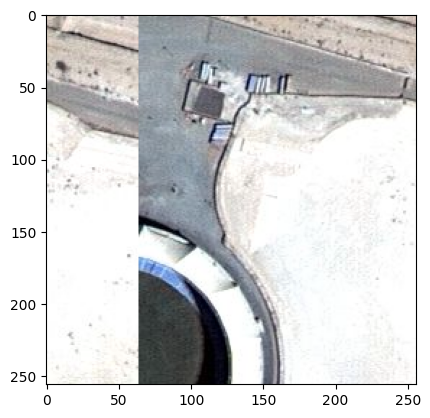

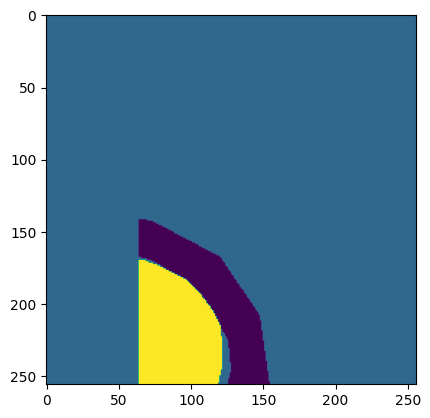

In [ ]:
# we print a shifted image and its mask to check the results
plt.imshow(imgs_shifted_h[0])
plt.show()

plt.imshow(masks_shifted_h[0])
plt.show()

We finally concatenate the new sets in a general set for images and in a general one for masks.

In [ ]:
# we concatenate original and augmented images and masks
imgs_aug = np.concatenate((imgs_subset, imgs_rotated_90, imgs_rotated_180, imgs_rotated_270,
                           imgs_flipped_h, imgs_flipped_v, imgs_shifted_v, imgs_shifted_h), axis=0)
masks_aug = np.concatenate((masks_subset, masks_rotated_90, masks_rotated_180, masks_rotated_270,
                            masks_flipped_h, masks_flipped_v, masks_shifted_v, masks_shifted_h), axis=0)

# then we shuffle everything in a consistent way
# so to reduce the possibility of giving the model unwanted positional information while keeping every image connected to its mask by the index
indices = np.arange(imgs_aug.shape[0])
np.random.shuffle(indices)

imgs_aug = imgs_aug[indices]
masks_aug = masks_aug[indices]

# we print the shapes of the concatenated and shuffled arrays
print(f"All images shape: {imgs_aug.shape}")
print(f"All masks shape: {masks_aug.shape}")

All images shape: (3128, 256, 256, 3)
All masks shape: (3128, 256, 256, 1)


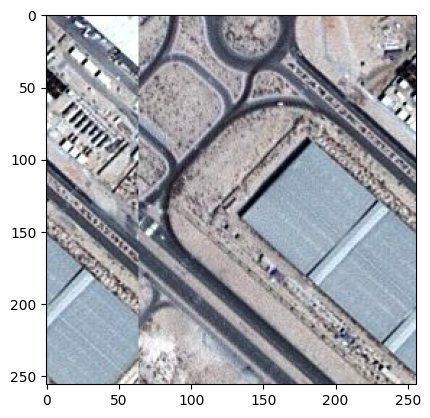

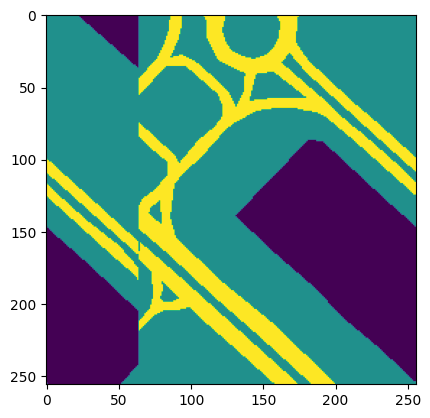

In [ ]:
# we check again that the process went fine
plt.imshow(imgs_aug[99])
plt.show()

plt.imshow(masks_aug[99])
plt.show()

## Train, validation and test sets

We split our new datasets into train, validation and test sets using the scikit learn function "train_test_split": we use it the first time to split into train set and validation-test set combined (respectively 80% and 20% of our datasets) and then we divide the latter into two equally sized parts (50% each of the combined set).

In [ ]:
# train and test_val sets (80% train, 20% test_val)
imgs_train, imgs_test_val, masks_train, masks_test_val = train_test_split(imgs_aug, masks_aug, test_size=0.2, random_state=42)

# we split test_val into test and validation sets (50% test, 50% validation from the 20% test_val)
imgs_test, imgs_val, masks_test, masks_val = train_test_split(imgs_test_val, masks_test_val, test_size=0.5, random_state=42)

# shapes of the resulting splits
print(f"Train images shape: {imgs_train.shape}")
print(f"Train masks shape: {masks_train.shape}")
print(f"Validation images shape: {imgs_val.shape}")
print(f"Validation masks shape: {masks_val.shape}")
print(f"Test images shape: {imgs_test.shape}")
print(f"Test masks shape: {masks_test.shape}")

Train images shape: (2502, 256, 256, 3)
Train masks shape: (2502, 256, 256, 1)
Validation images shape: (313, 256, 256, 3)
Validation masks shape: (313, 256, 256, 1)
Test images shape: (313, 256, 256, 3)
Test masks shape: (313, 256, 256, 1)


## U-Net (Question 1)

### Define a model function (Question 2, 3, 4 and 5 highlited in the code)
First we define a function to build our model so that we will be able to use it in hyperparameter tuning. As written in the exam, since my idea was to build a substructure to then use it multiple times, i build a standard convolutional block that is then implemented in three different ways:

*   in the encoder block, followed by a max pooling layer
*   in the bottleneck, as it is
*   in the decoder block, preceeded by a Conv2DTranspose layer and the concatenate layer for the skip-connection

The encoder and decoder blocks are then repeated 4 times.


In [ ]:
def build_model(hp):
    num_classes = 6

    # we define filters based on three base numbers choice of filters
    base_filters = hp.Choice('base_filters', values=[8, 12, 16])
    filters = [base_filters * (i + 1) for i in range(5)]

    # we choose a dropout rate for all dropout layers
    dropout_rate = hp.Float('dropout_rate', 0.1, 0.5, step=0.1)

    # and a L2 regularization value
    l2_reg = hp.Float('l2', 1e-5, 1e-2, sampling='log')

    # then we choose the batch size
    batch_size = hp.Choice('batch_size', values=[16, 32, 64])

    # Question 2
    # we perform normalization through a lambda layer, by dividing each value by the max possible (255)
    inputs = Input(shape=(256, 256, 3))
    s = Lambda(lambda x: x / 255)(inputs)

    # Question 5
    # the base convolutional block
    def conv_block(inputs, num_filters, dropout_rate, l2_reg):
        x = Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same',
                   kernel_regularizer=l2(l2_reg))(inputs)
        x = Dropout(dropout_rate)(x)
        x = Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same',
                   kernel_regularizer=l2(l2_reg))(x)
        return x

    # the encoder and the decoder block
    def encoder_block(inputs, num_filters, dropout_rate, l2_reg):
        x = conv_block(inputs, num_filters, dropout_rate, l2_reg)
        p = MaxPooling2D((2, 2))(x)
        return x, p

    def decoder_block(inputs, skip_features, num_filters, dropout_rate, l2_reg):
        x = Conv2DTranspose(num_filters, (2, 2), strides=(2, 2), padding='same')(inputs)
        x = concatenate([x, skip_features])
        x = conv_block(x, num_filters, dropout_rate, l2_reg)
        return x

    # encoder
    c1, p1 = encoder_block(s, filters[0], dropout_rate, l2_reg)
    c2, p2 = encoder_block(p1, filters[1], dropout_rate, l2_reg)
    c3, p3 = encoder_block(p2, filters[2], dropout_rate, l2_reg)
    c4, p4 = encoder_block(p3, filters[3], dropout_rate, l2_reg)

    # bottleneck
    c5 = conv_block(p4, filters[4], dropout_rate, l2_reg)

    # decoder
    u6 = decoder_block(c5, c4, filters[3], dropout_rate, l2_reg)
    u7 = decoder_block(u6, c3, filters[2], dropout_rate, l2_reg)
    u8 = decoder_block(u7, c2, filters[1], dropout_rate, l2_reg)
    u9 = decoder_block(u8, c1, filters[0], dropout_rate, l2_reg)

    # Question 3
    # the output layer
    outputs = Conv2D(num_classes, (1, 1), padding='same', activation='softmax')(u9)

    # model definition
    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy", # Question 4
                  metrics=["accuracy"])

    return model

## Tuning (Question 5 part c)

### Solving an issue with keras tuner
The keras tuner automathically stores the tuner after its definition, which means that after being run the first time, the next run it just recovers the previous tuner. To address this i store the tuner results in a directory and everytime i delete it. This is done for this project's sake, since it is necessary for everything to run properly.

In [ ]:
# we define the directory path
directory_path = 'my_project_dir/my_project'

# then check if the directory exists
if os.path.exists(directory_path):
    shutil.rmtree(directory_path)
    print(f"Deleted existing tuner results in: {directory_path}")
else:
    print(f"No existing tuner results found in: {directory_path}")

No existing tuner results found in: my_project_dir/my_project


In [ ]:
# finally we delete it
if not os.path.exists(directory_path):
    print(f"Directory {directory_path} successfully deleted.")
else:
    print(f"Directory {directory_path} still exists.")

Directory my_project_dir/my_project successfully deleted.


### Actual tuning
The tuning is performed through RandomSearch to make it more computationally efficient.

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='my_project_dir',
    project_name='my_project'
)

# early stopping
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

We perform the search and store the best parameters.

In [ ]:
# we search for the best hyperparameter configuration
tuner.search(imgs_train, masks_train, epochs=1, validation_data=(imgs_val, masks_val), callbacks=[stop_early])

Trial 5 Complete [00h 01m 31s]
val_accuracy: 0.7121489644050598

Best val_accuracy So Far: 0.7233960628509521
Total elapsed time: 00h 06m 59s


In [ ]:
# we retrieve the best model and hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# the final hyperparameters
print("Final selected hyperparameters:")
for key, value in best_hps.values.items():
    print(f"{key}: {value}")

Final selected hyperparameters:
base_filters: 16
dropout_rate: 0.1
l2: 1.3784059518427684e-05
batch_size: 64


### Model summary

In [ ]:
model = tuner.hypermodel.build(best_hps)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_1 (Lambda)         │ (None, 256, 256, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 256, 256, 16)   │            448 │ lambda_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_9 (Dropout)       │ (None, 256, 256, 16)   │              0 │ conv2d_19[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_20 (Conv2D)        │ (None, 256, 256, 16)   │          2,320 │ dropout_9[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 128, 128, 16)   │              0 │ conv2d_20[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_21 (Conv2D)        │ (None, 128, 128, 32)   │          4,640 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_10 (Dropout)      │ (None, 128, 128, 32)   │              0 │ conv2d_21[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_22 (Conv2D)        │ (None, 128, 128, 32)   │          9,248 │ dropout_10[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_5           │ (None, 64, 64, 32)     │              0 │ conv2d_22[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 64, 64, 48)     │         13,872 │ max_pooling2d_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_11 (Dropout)      │ (None, 64, 64, 48)     │              0 │ conv2d_23[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 64, 64, 48)     │         20,784 │ dropout_11[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_6           │ (None, 32, 32, 48)     │              0 │ conv2d_24[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_25 (Conv2D)        │ (None, 32, 32, 64)     │         27,712 │ max_pooling2d_6[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_12 (Dropout)      │ (None, 32, 32, 64)     │              0 │ conv2d_25[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_26 (Conv2D)        │ (None, 32, 32, 64)     │         36,928 │ dropout_12[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_7      

 Total params: 468,694 (1.79 MB)

 Trainable params: 468,694 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

## Training
We perform the training using the best hyperparameters.

In [ ]:
epochs = 1
history = model.fit(imgs_train, masks_train, epochs=epochs, validation_data=(imgs_val, masks_val), batch_size=best_hps.get('batch_size'))

40/40 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.4890 - loss: 1.2871 - val_accuracy: 0.6288 - val_loss: 1.1406


## Evaluation (Question 6)

We evaluate the model on the test set.

In [ ]:
test_loss, test_accuracy = model.evaluate(imgs_test, masks_test)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.6359 - loss: 1.1206
Test loss: 1.1242
Test accuracy: 0.6351


### Accuracy and loss plotting
We plot the graphs of accuracy and loss in training and validation with respect to the number of epochs, to check whether there is convergence and a plateau is reached.

In [ ]:
# we retrieve metrics from the history
train_accuracy = history.history.get('accuracy', None)
val_accuracy = history.history.get('val_accuracy', None)

# if they are retrieved correctly we print the last training and validation accuracy
if train_accuracy and val_accuracy:
    print(f'Final Training Accuracy: {train_accuracy[-1]}')
    print(f'Final Validation Accuracy: {val_accuracy[-1]}')
else:
    print("Accuracy metrics not found in history.")

Final Training Accuracy: 0.5347244739532471
Final Validation Accuracy: 0.6288379430770874


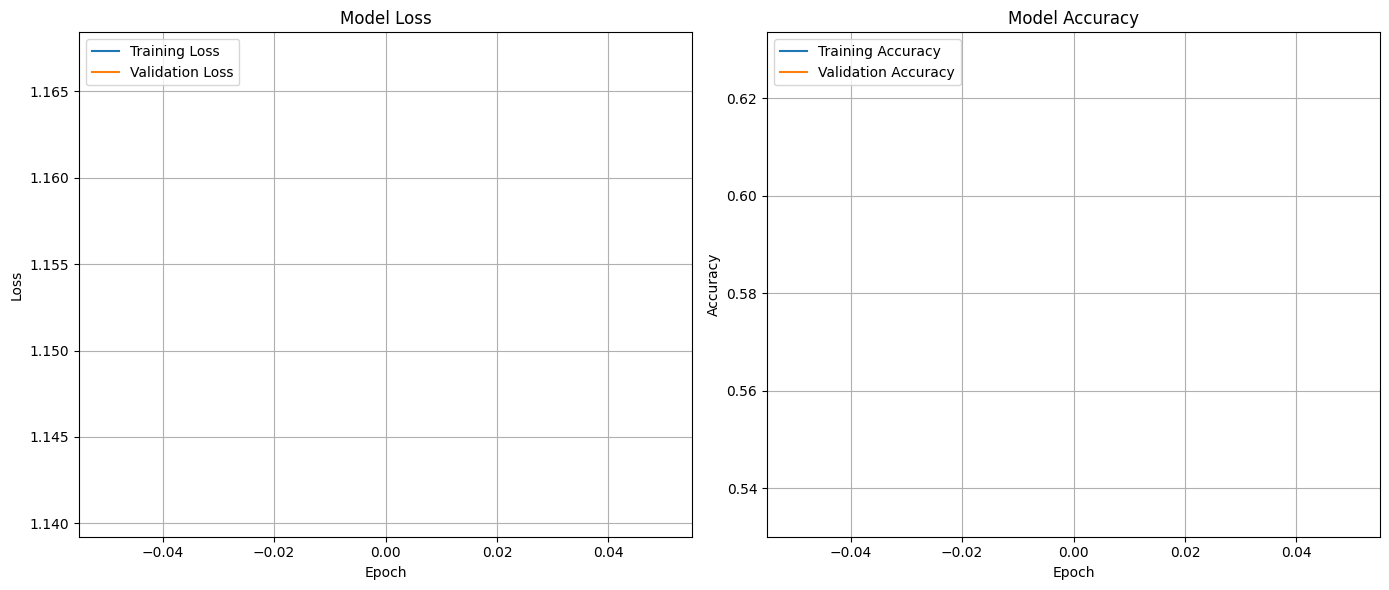

In [ ]:
# we create a figure and a set of subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# we plot training & validation loss values
ax[0].plot(history.history['loss'], label='Training Loss')
ax[0].plot(history.history['val_loss'], label='Validation Loss')
ax[0].set_title('Model Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend(loc='upper left')
ax[0].grid(True)

# and training & validation accuracy values
if 'accuracy' in history.history:
    ax[1].plot(history.history['accuracy'], label='Training Accuracy')
    ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax[1].set_title('Model Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend(loc='upper left')
    ax[1].grid(True)

# we adjust layout to prevent overlap
plt.tight_layout()

plt.show()

### Predictions visualization
To visualize every predicted mask and confront it with the true mask, we plot the sample composed of the image and the respective masks. I added a slider and a menu to make it easier to access every prediction.

In [ ]:
# predict on test data
predictions = model.predict(imgs_test)

# we convert predictions to class labels
predicted_labels = np.argmax(predictions, axis=-1)

# we define the function to display a sample
def display_sample(index):
    plt.figure(figsize=(12, 4))

    # image
    plt.subplot(1, 3, 1)
    plt.title('Image')
    plt.imshow(imgs_test[index])
    plt.axis('off')

    # true mask
    plt.subplot(1, 3, 2)
    plt.title('True Mask')
    plt.imshow(masks_test[index])
    plt.axis('off')

    # predicted mask
    plt.subplot(1, 3, 3)
    plt.title('Predicted Mask')
    plt.imshow(predicted_labels[index])
    plt.axis('off')

    plt.show()

# interactive slider and menu
index_slider = IntSlider(min=0, max=len(imgs_test)-1, step=1, value=0, description='Index:')
index_dropdown = Dropdown(
    options=[(f'Image {i}', i) for i in range(len(imgs_test))],
    value=0,
    description='Select Image:'
)

# update function
def update_index(value):
    index_slider.value = value
    index_dropdown.value = value

# sync slider and dropdown
def on_slider_change(change):
    if change['name'] == 'value':
        index_dropdown.value = change['new']

def on_dropdown_change(change):
    if change['name'] == 'value':
        index_slider.value = change['new']

index_slider.observe(on_slider_change)
index_dropdown.observe(on_dropdown_change)

# interactive display
interactive_plot = VBox([index_dropdown])
interactive_ui = interactive(display_sample, index=index_slider)

display(interactive_plot, interactive_ui)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step


interactive(children=(IntSlider(value=0, description='Index:', max=312), Output()), _dom_classes=('widget-inte…

### F1 scores
Finally, we return the f1 scores, macro, micro and weighted, to check the model performance with respect to this combination of precision and recall.
As one could possibly expect, the macro score is significantly lower than the other two since it does not take into account class imbalance which is very important in segmentation (the background usally takes a lot of every image space)

In [ ]:
# Flatten the ground true and predicted labels for F1 score calculation
true_flat = masks_test.flatten()
pred_flat = predicted_labels.flatten()

# Calculate F1 scores
f1_macro = f1_score(true_flat, pred_flat, average='macro')
f1_micro = f1_score(true_flat, pred_flat, average='micro')
f1_weighted = f1_score(true_flat, pred_flat, average='weighted')

print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")

F1 Macro: 0.2806
F1 Micro: 0.6351
F1 Weighted: 0.5326


## Conclusion
The predictions are quite close to the given masks, sometimes defining some details even more precisely but other times failing to grasp boundaries in images with low contrast between the parts. Performance could be improved by using the full dataset and increasing model complexity, performing tuning on more parameters and maybe increasing the number of epochs.